In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_selection import VarianceThreshold

from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
# Upload manually cleaning data
from google.colab import files
uploaded = files.upload()

Saving design_matrix_ver_1.csv to design_matrix_ver_1 (2).csv


In [17]:
df = pd.read_csv("design_matrix_ver_1.csv")
df = df.set_index(['HEATID', 'DATETIME'])
df.head()

,,16A,25A,25A1,26A,3A,3A (shop pipe waste),3ACh,3B23,Aluminum briquet,Artificial graphite 0.1-2.5 mm,...,VALNI,VALAS,VALSN,VALN,TEMP,VALO2_PPM,O2_AMOUNT,GAS_AMOUNT,INJ_AMOUNT_CARBON,MW
HEATID,DATETIME,,,,,,,,,,,,,,,,,,,,,
5F0002,2015-01-01 01:31:00.000000000,0.0,0.0,0.0,0.0,105928.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,1627.0,383.000000,3659.0,1160.0,1021.0,48.625
5F0003,2015-01-01 02:17:30.000000000,0.0,0.0,0.0,0.0,108033.0,0.0,0.0,0.0,0.0,0.0,...,0.1075,0.0053,0.0068,0.0361,1641.0,683.000000,3469.0,1117.0,957.0,48.625
5F0004,2015-01-01 03:17:30.000000000,0.0,0.0,0.0,0.0,128245.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,1636.0,700.000000,3605.0,1204.0,789.0,47.375
5F0005,2015-01-01 04:06:00.000000000,0.0,0.0,0.0,0.0,106941.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,1630.0,625.333333,3678.0,1191.0,812.0,49.250
5F0006,2015-01-01 04:54:24.000000000,0.0,0.0,0.0,0.0,127035.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,1622.0,654.600000,3655.0,1171.0,882.0,49.875


In [18]:
# Remove features with perfectly 0 variance
df = df.drop(columns=df.columns[df.var(axis='rows') == 0])

# Split the dataset into those with or without steel chemistry.
# For now, remove the steel chemistry feature as it is mostly (~85%) empty.
df = df[df['VALC'].isna()]

# Drop columns that are all NaN
df = df.dropna(axis='columns', how='all')

# Drop rows that contain any NaN
df = df.dropna(axis='rows')

# Define feature and target columns
FEATURES = list(df.columns[:-1])
TARGET = 'MW'

df.describe()

,16A,25A,25A1,26A,3A,3ACh,3B23,Aluminum briquet,Artificial graphite 0.1-2.5 mm,B11,...,Secondary aluminum AV 87 Added,Steel scrap G/B 25A Added,total_charging_time,num_baskets,TEMP,VALO2_PPM,O2_AMOUNT,GAS_AMOUNT,INJ_AMOUNT_CARBON,MW
count,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,...,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000
mean,5046.419135,136.103542,2292.335285,11.216368,113957.310271,1066.367157,2.877654,0.011531,7.033292,147.269824,...,3.791319,0.590148,2659.102359,2.068299,1635.502847,982.395617,4292.221335,762.949441,901.256519,48.570531
std,4942.693717,904.675505,4836.046339,316.184722,25724.755668,5536.199276,154.345988,1.088153,76.715107,2408.968325,...,185.910261,76.744259,8917.298415,0.350561,16.725183,698.369872,501.586274,150.643999,311.330350,8.787742
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,1517.000000,1.000000,0.000000,0.000000,0.000000,-999.999000
25%,0.000000,0.000000,0.000000,0.000000,109894.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1020.000000,2.000000,1624.500000,726.125000,3958.000000,664.000000,696.000000,47.250000
50%,5060.000000,0.000000,0.000000,0.000000,121168.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1080.000000,2.000000,1635.000000,862.000000,4274.000000,752.000000,886.000000,48.750000
75%,9253.500000,0.000000,0.000000,0.000000,127959.500000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1260.000000,2.000000,1646.000000,996.000000,4598.000000,838.000000,1084.000000,50.375000
max,49366.000000,20854.000000,24776.000000,13890.000000,139916.000000,69506.000000,10052.000000,120.000000,1900.000000,76639.000000,...,24000.000000,9980.000000,86160.000000,8.000000,1737.000000,9999.000000,8886.000000,2209.000000,10884.000000,85.000000


In [19]:
# Filter physically impossible MW values (based on process knowledge)
df = df[(df['MW'] > 35) & (df['MW'] < 70)]

In [20]:
# Train/test split
df_train, df_test = train_test_split(df, train_size=0.7)

df_train.describe()

,16A,25A,25A1,26A,3A,3ACh,3B23,Aluminum briquet,Artificial graphite 0.1-2.5 mm,B11,...,Secondary aluminum AV 87 Added,Steel scrap G/B 25A Added,total_charging_time,num_baskets,TEMP,VALO2_PPM,O2_AMOUNT,GAS_AMOUNT,INJ_AMOUNT_CARBON,MW
count,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.0,11740.000000,11740.000000,...,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000
mean,5088.077002,131.445145,2294.031005,11.460818,114393.396082,1049.269847,2.881175,0.0,6.902044,131.924787,...,4.447104,0.850085,2655.153322,2.071721,1635.477525,977.672467,4303.900085,764.167291,903.947785,48.770273
std,4950.189975,876.796934,4824.657688,328.062646,25102.040364,5444.110128,157.911800,0.0,76.654996,2327.234025,...,222.675226,92.107818,8849.606335,0.334262,16.754566,685.532201,480.815717,149.828018,315.345591,2.807010
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,1517.000000,1.000000,2632.000000,360.000000,0.000000,35.250000
25%,0.000000,0.000000,0.000000,0.000000,110337.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,1020.000000,2.000000,1624.500000,723.800000,3968.000000,664.000000,699.000000,47.250000
50%,5080.000000,0.000000,0.000000,0.000000,121251.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,1080.000000,2.000000,1634.833333,860.500000,4281.000000,752.000000,889.000000,48.750000
75%,9350.500000,0.000000,0.000000,0.000000,127944.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,1260.000000,2.000000,1646.000000,996.000000,4604.000000,839.000000,1086.000000,50.375000
max,31780.000000,20854.000000,24776.000000,13890.000000,139867.000000,69506.000000,10052.000000,0.0,1900.000000,76639.000000,...,24000.000000,9980.000000,86160.000000,7.000000,1737.000000,9999.000000,7768.000000,2209.000000,10884.000000,69.500000


In [21]:
df_test.describe()

,16A,25A,25A1,26A,3A,3ACh,3B23,Aluminum briquet,Artificial graphite 0.1-2.5 mm,B11,...,Secondary aluminum AV 87 Added,Steel scrap G/B 25A Added,total_charging_time,num_baskets,TEMP,VALO2_PPM,O2_AMOUNT,GAS_AMOUNT,INJ_AMOUNT_CARBON,MW
count,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,...,5032.000000,5032.0,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000
mean,4999.461844,147.934420,2284.637520,10.955882,114030.311010,1093.471383,2.948927,0.014905,7.533784,181.359897,...,2.336248,0.0,2583.398251,2.075715,1635.534449,991.459229,4298.647854,764.787957,898.363871,48.846930
std,4923.629669,967.385991,4846.772233,291.368611,26083.815625,5703.772102,147.943635,1.057282,77.902709,2588.276677,...,21.640800,0.0,8726.605090,0.349390,16.482039,725.898415,476.391882,147.003223,295.033946,2.778191
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,1.000000,1551.571429,26.000000,2774.000000,286.000000,117.000000,36.000000
25%,0.000000,0.000000,0.000000,0.000000,109941.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,1020.000000,2.000000,1624.666667,732.000000,3965.000000,668.000000,691.000000,47.375000
50%,5050.000000,0.000000,0.000000,0.000000,121309.500000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,1080.000000,2.000000,1635.000000,863.550000,4271.500000,754.000000,883.000000,48.875000
75%,8983.250000,0.000000,0.000000,0.000000,128078.250000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,1260.000000,2.000000,1646.000000,994.000000,4595.250000,837.000000,1078.000000,50.500000
max,49366.000000,19412.000000,23102.000000,10260.000000,139916.000000,66130.000000,7594.000000,75.000000,1010.000000,60400.000000,...,1000.000000,0.0,85560.000000,8.000000,1716.250000,9999.000000,8886.000000,2037.000000,2176.000000,67.500000


# Helper Function

In [22]:
def get_regression_metrics(model, X, y_true):   # This is the same evaluation function from tutorial 04, which we can also use here.
    """
    Get a dicionary with regression metrics:

    model: sklearn model with predict method
    X: feature matrix
    y_true: ground truth labels
    """
    y_predicted = model.predict(X)

    mae = np.sum(abs(y_true - y_predicted)) / len(y_true)
    mse = np.sum((y_true - y_predicted)**2) / len(y_true)
    maximum_error = np.max(abs(y_true - y_predicted))
    mape =  np.sum(abs((y_true - y_predicted)/y_true)) / len(y_true)

    metrics_dict = {
        'mae': mae,
        'mse': mse,
        'max_error': maximum_error,
        'mape': mape
    }

    return metrics_dict

In [37]:
def plot_predictions(model, X, y_true, title='Model Results'):
    '''
    Makes a scatterplot that compares y_true and y_predicted.

    model: sklearn model with predict method
    X: feature matrix
    y_true: ground truth labels
    '''

    fig, ax = plt.subplots()

    ax.scatter(
        y_true,
        model.predict(X),
        alpha=0.3
    )

    ax.plot(
        [-9999, 9999],
        [-9999, 9999]
    )

    ax.set_ylim(np.min(y_true), np.max(y_true))
    ax.set_xlim(np.min(y_true), np.max(y_true))

    ax.set_title(title)
    ax.set_xlabel('True Values')
    ax.set_ylabel('Predicted Values')
    plt.show()

# Kernel Ridge Regression (RBF) Model (Fiona)

In [24]:
# Define model
krr = KernelRidge(kernel='rbf')

In [25]:
# Set up pipeline
krr_pipeline = Pipeline([
    ('variance threshold', VarianceThreshold()),
    ('scaling', StandardScaler()),
    ('krr', krr)
])

In [42]:
# Define parameter grid
param_grid_krr = {
    'variance threshold__threshold': [0],
    'krr__alpha': [0.001, 0.01, 0.1, 1, 10],
    'krr__gamma': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
}

# Randomized search for best parameters
random_param_grid_krr = RandomizedSearchCV(
    krr_pipeline,
    param_distributions=param_grid_krr,
    n_iter=20,
    cv=5,
    verbose=2,
    n_jobs=-1
)

In [43]:
# Fit model
random_param_grid_krr.fit(df_train[FEATURES], df_train[TARGET])

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('variance threshold',
                                              VarianceThreshold()),
                                             ('scaling', StandardScaler()),
                                             ('krr',
                                              KernelRidge(kernel='rbf'))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'krr__alpha': [0.001, 0.01, 0.1, 1, 10],
                                        'krr__gamma': [1e-05, 0.0001, 0.001,
                                                       0.01, 0.1],
                                        'variance threshold__threshold': [0]},
                   verbose=2)

In [45]:
# Display best model
print(random_param_grid_krr.best_estimator_)

Pipeline(steps=[('variance threshold', VarianceThreshold(threshold=0)),
                ('scaling', StandardScaler()),
                ('krr', KernelRidge(alpha=0.001, gamma=0.0001, kernel='rbf'))])


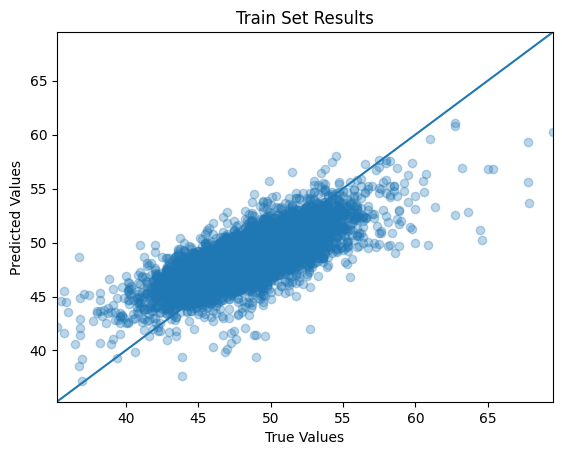

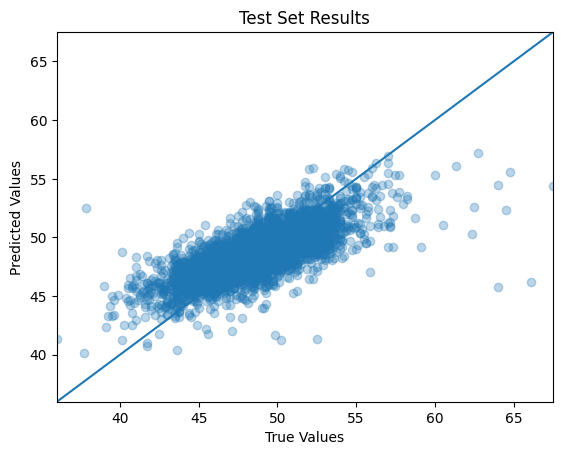

In [46]:
# Plot predictions
plot_predictions(random_param_grid_krr.best_estimator_, df_train[FEATURES], df_train[TARGET], title='Train Set Results')
plot_predictions(random_param_grid_krr.best_estimator_, df_test[FEATURES], df_test[TARGET], title='Test Set Results')

In [47]:
# Evaluate regression metrics
metrics_train = get_regression_metrics(random_param_grid_krr.best_estimator_, df_train[FEATURES], df_train[TARGET])
metrics_test = get_regression_metrics(random_param_grid_krr.best_estimator_, df_test[FEATURES], df_test[TARGET])

print("Training metrics:", metrics_train)
print("Test metrics:", metrics_test)

Training metrics: {'mae': np.float64(1.3819697555867665), 'mse': np.float64(3.473020212147746), 'max_error': 14.371243714813318, 'mape': np.float64(0.02852513051478651)}
Test metrics: {'mae': np.float64(1.3952809162096647), 'mse': np.float64(3.6310217516288708), 'max_error': 19.950679612375097, 'mape': np.float64(0.028649925851038153)}
